In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from prophet import Prophet 
import warnings 
warnings.filterwarnings('ignore')

In [168]:
#Load the dataset
prophet_df = pd.read_csv('Data/Processed/prophet_data.csv')

In [169]:
prophet_df.head()

,ds,y
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [170]:
prophet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ds      604 non-null    str    
 1   y       604 non-null    float64
dtypes: float64(1), str(1)
memory usage: 9.6 KB


In [171]:
prophet_df['ds'] = pd.to_datetime(prophet_df['ds']) 

In [172]:
prophet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      604 non-null    datetime64[us]
 1   y       604 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 9.6 KB


In [173]:
# Train-Test split 20-80%
train_size = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

In [174]:
print(train.shape)
print(test.shape)

(483, 2)
(121, 2)


In [175]:
# model 
model = Prophet(
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=True
)


In [176]:
model.fit(train)

16:50:28 - cmdstanpy - INFO - Chain [1] start processing
16:50:28 - cmdstanpy - INFO - Chain [1] done processing


In [177]:
future = model.make_future_dataframe(
    periods=len(test),
    freq="D"
)

In [178]:
# Generate predection 
forecast = model.predict(
    future
)

In [179]:
forecast[
    ["ds","yhat","yhat_lower","yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
599,2011-11-14,44580.920620,32871.587030,57030.710781
600,2011-11-15,48054.028400,36395.974369,60322.474863
601,2011-11-16,43872.205701,31252.578584,56946.259693
602,2011-11-17,50472.604476,37603.053578,62298.078761
603,2011-11-18,41863.997254,30728.377864,53780.616000


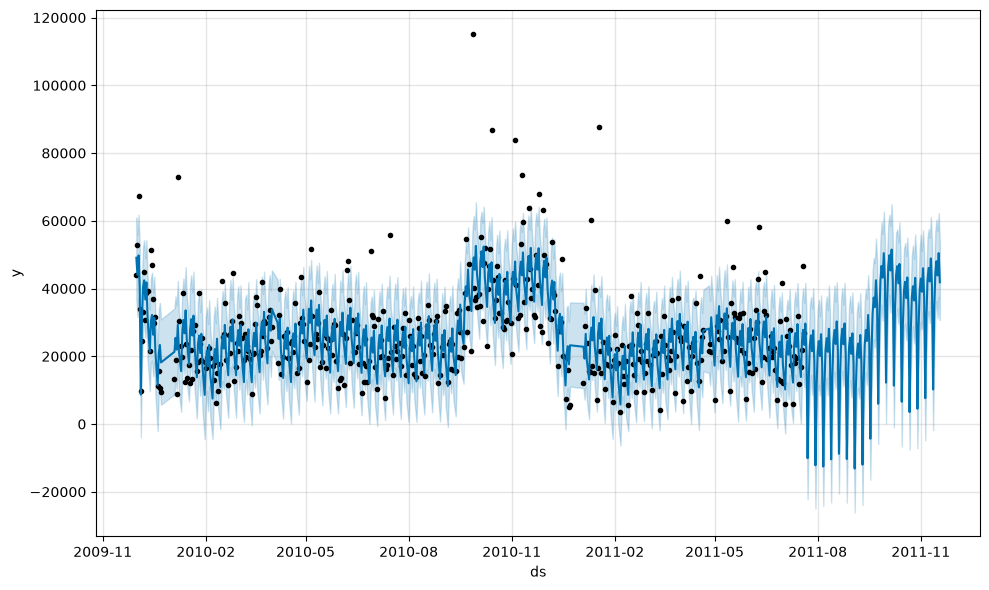

In [180]:
#Plot forcast 
fig1 = model.plot(forecast)
plt.show()

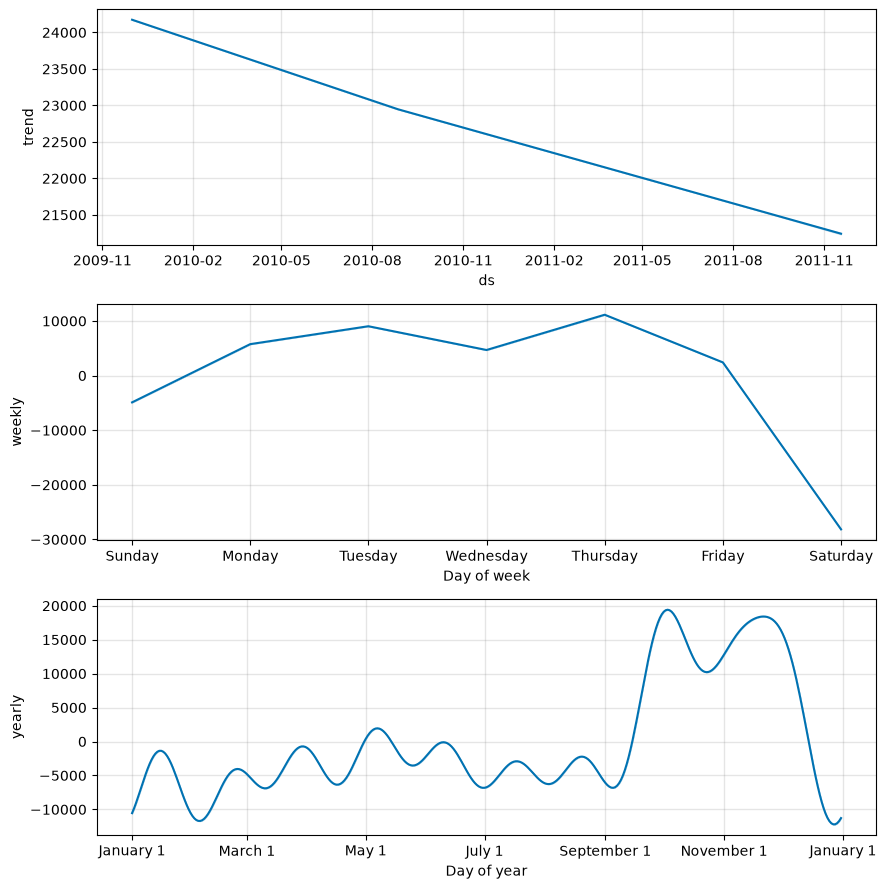

In [181]:
fig2 = model.plot_components(forecast)
plt.show()

Evaluation


In [182]:
forecast_test = forecast.tail(len(test))

In [183]:
comparison = pd.DataFrame({
    "Date": test["ds"].values,
    "Actual": test["y"].values,
    "Predicted": forecast_test["yhat"].values
})

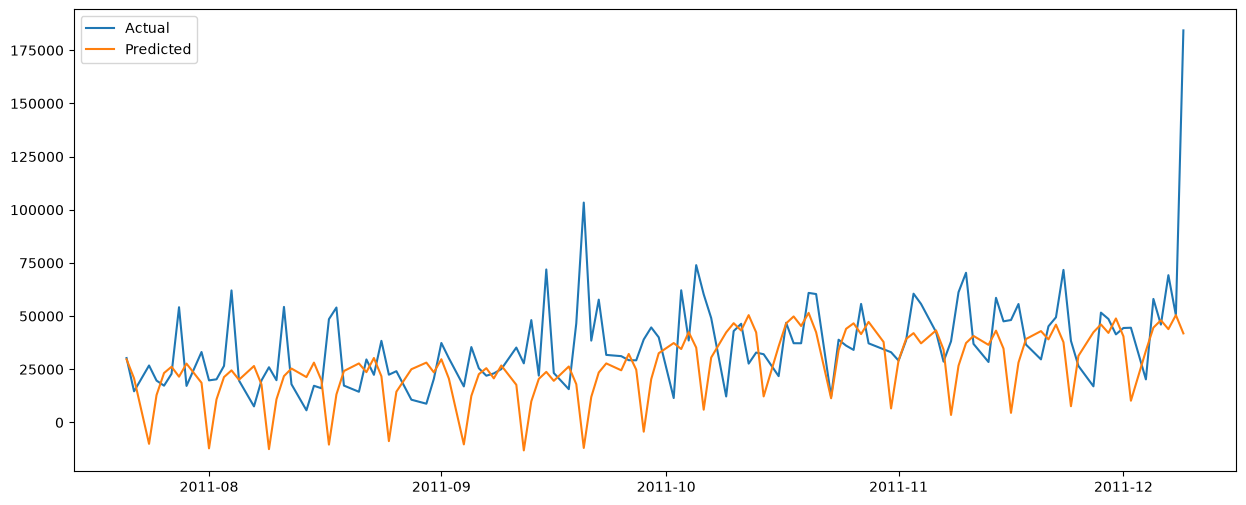

In [184]:
plt.figure(figsize=(15,6))

plt.plot(
    comparison["Date"],
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison["Date"],
    comparison["Predicted"],
    label="Predicted"
)

plt.legend()
plt.show()

In [185]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    comparison["Actual"],
    comparison["Predicted"]
)

rmse = np.sqrt(
    mean_squared_error(
        comparison["Actual"],
        comparison["Predicted"]
    )
)

mape = np.mean(
    np.abs((comparison["Actual"] - comparison["Predicted"]) / comparison["Actual"])) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 17675.87365164595
RMSE: 26577.34227324998
MAPE: 52.9994807629168
